In [1]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms
import helper
import numpy as np

In [2]:
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])

trainset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# Download and load the test data
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)

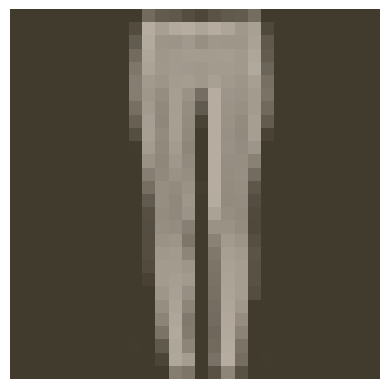

In [4]:
image, label = next(iter(trainloader))
helper.imshow(image[0,:]);

In [5]:
class MY_MODEL(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
        
        # Dropout module with 0.2 drop probability
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc4(x)
        
        return x

In [6]:
model = MY_MODEL()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

In [7]:
epochs = 50
steps = 0
train_losses, test_losses = [], []

for e in range(epochs):
    running_loss = 0
    for images, labels in trainloader:
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    else:
        test_loss = 0
        accuracy = 0
        with torch.no_grad():
            model.eval()
            for images, labels in testloader:
                output = model(images)
                loss = criterion(output, labels)
                test_loss += loss.item()
                
                ps = torch.softmax(output, dim=1)
                top_p, top_class = ps.topk(1, dim=1)
                equals = top_class == labels.view(*top_class.shape)
                accuracy += torch.mean(equals.type(torch.FloatTensor))

        model.train()
        train_losses.append(running_loss/len(trainloader))
        test_losses.append(test_loss/len(testloader))
        
        print("Epoch: {}/{}.. ".format(e+1, epochs),
              "Training Loss: {:.3f}.. ".format(running_loss/len(trainloader)),
              "Test Loss: {:.3f}.. ".format(test_loss/len(testloader)),
              "Test Accuracy: {:.3f}".format(accuracy/len(testloader)))

Epoch: 1/50..  Training Loss: 0.602..  Test Loss: 0.481..  Test Accuracy: 0.825
Epoch: 2/50..  Training Loss: 0.488..  Test Loss: 0.456..  Test Accuracy: 0.832
Epoch: 3/50..  Training Loss: 0.452..  Test Loss: 0.446..  Test Accuracy: 0.835
Epoch: 4/50..  Training Loss: 0.433..  Test Loss: 0.419..  Test Accuracy: 0.850
Epoch: 5/50..  Training Loss: 0.425..  Test Loss: 0.424..  Test Accuracy: 0.856
Epoch: 6/50..  Training Loss: 0.413..  Test Loss: 0.394..  Test Accuracy: 0.858
Epoch: 7/50..  Training Loss: 0.406..  Test Loss: 0.423..  Test Accuracy: 0.849
Epoch: 8/50..  Training Loss: 0.398..  Test Loss: 0.395..  Test Accuracy: 0.860
Epoch: 9/50..  Training Loss: 0.397..  Test Loss: 0.411..  Test Accuracy: 0.854
Epoch: 10/50..  Training Loss: 0.387..  Test Loss: 0.383..  Test Accuracy: 0.868
Epoch: 11/50..  Training Loss: 0.387..  Test Loss: 0.379..  Test Accuracy: 0.865
Epoch: 12/50..  Training Loss: 0.374..  Test Loss: 0.374..  Test Accuracy: 0.869
Epoch: 13/50..  Training Loss: 0.375.

In [8]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt

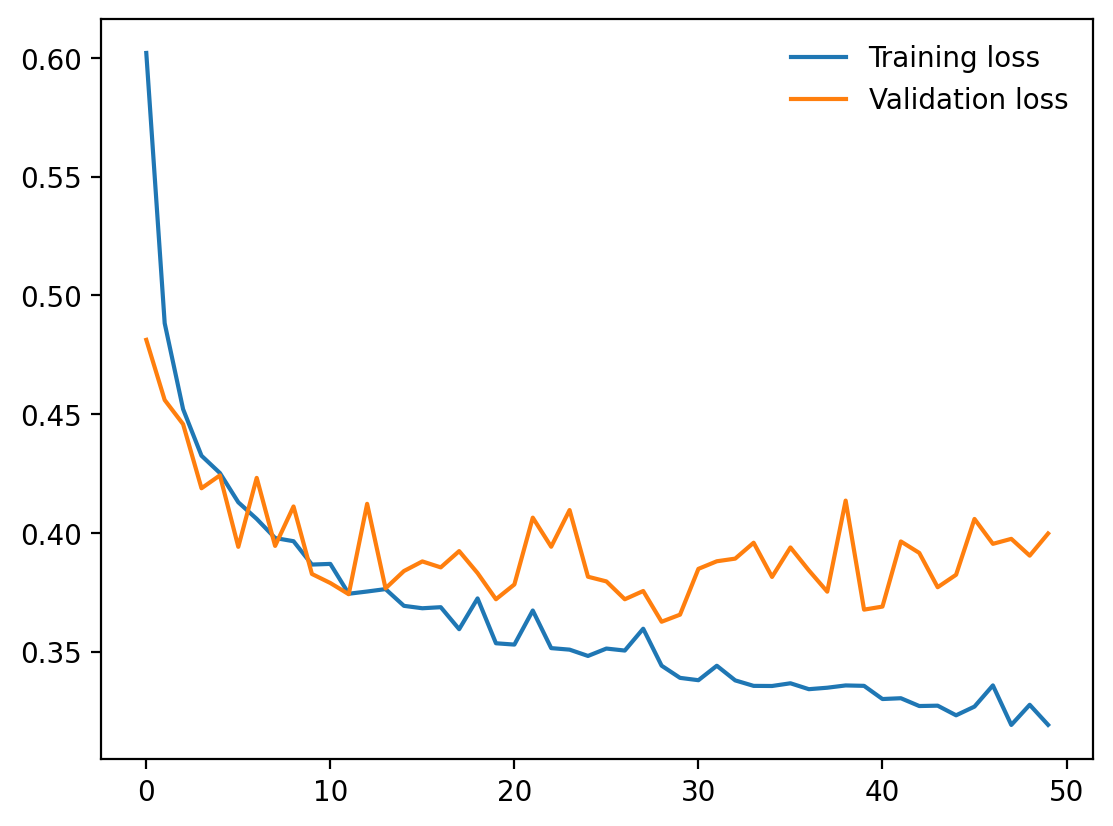

In [9]:
plt.plot(train_losses, label='Training loss')
plt.plot(test_losses, label='Validation loss')
plt.legend(frameon=False)
plt.show()

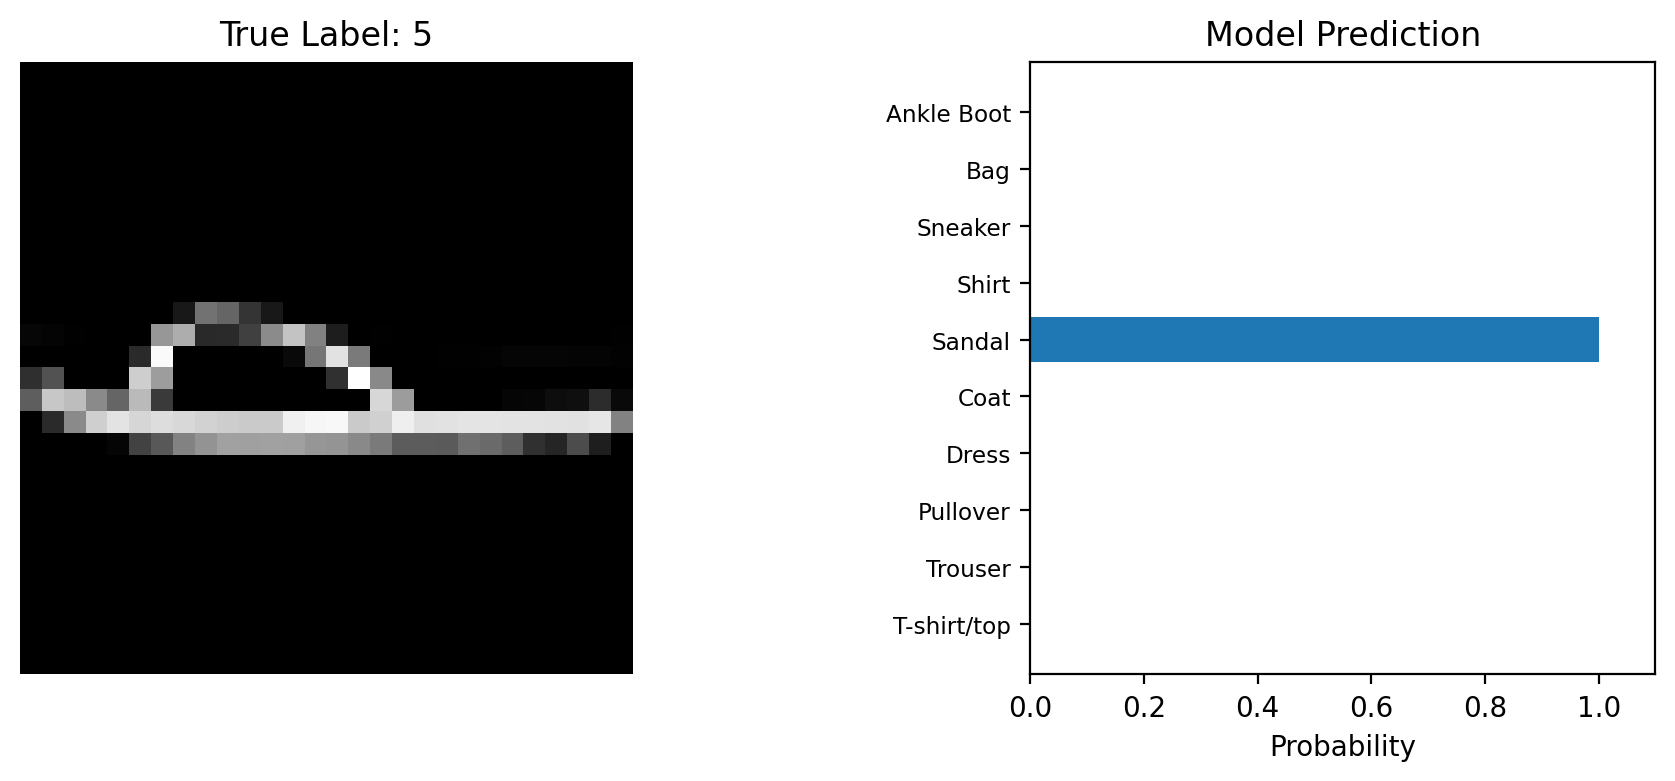

In [10]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
import numpy as np

# Get an image and label from the testloader
dataiter = iter(testloader)
images, labels = next(dataiter)
img = images[1]
label = labels[1]

# Flatten and forward pass
with torch.no_grad():
    output = model(img) 
    ps = torch.softmax(output, dim=1).squeeze().numpy()  # class probabilities

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Left: the input image
ax1.imshow(img.squeeze(), cmap='Greys_r')
ax1.axis('off')
ax1.set_title(f"True Label: {label.item()}")

# Right: class probabilities
ax2.barh(np.arange(10), ps)
ax2.set_aspect(0.1)
ax2.set_yticks(np.arange(10))
ax2.set_yticklabels(['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                     'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot'], size='small')
ax2.set_xlim(0, 1.1)
ax2.set_xlabel('Probability')
ax2.set_title('Model Prediction')

plt.tight_layout()
plt.show()

In [11]:
torch.save(model.state_dict(), 'ERFAN_MODEL.pth')

In [12]:
state_dict = torch.load('ERFAN_MODEL.pth')
print(state_dict.keys())
model.load_state_dict(state_dict)

odict_keys(['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias', 'fc4.weight', 'fc4.bias'])


<All keys matched successfully>